## Introdution

*The Cox-Ingersoll-Ross (CIR)* model is a mean-reverting stochastic process widely used for modeling interest rates, volatility, and other quantities that must remain non-negative.

### The SDE

$dr(t)= \kappa(\theta-r(t))dt+\sigma \sqrt{r(t)} dW(t)$

|  Symbol  |  Meaning  |
|----------|-----------|
|  $r(t)$  |  Interest rate at time $t$  |
|  $\kappa$  |  Speed of mean reversion ($\kappa > 0$)  |	
|  $\theta$  |  Long-term mean level ($\theta > 0$)  |
|  $\sigma$  |  Volatility parameter ($\sigma > 0$)  |
|  $W(t)$  |  Standard Brownian motion  |


## Why CIR is Special
Unlike the *Vasicek model* (which uses $\sigma\,dW$ with constant volatility), CIR uses $\sigma\sqrt{r}\,dW$. This square-root term ensures:
1. *Mean reversion* — the process is pulled toward $\theta$
2. *Positivity* — rates cannot go negative (if the Feller condition holds)
3. *Volatility scaling* — volatility is proportional to $\sqrt{r}$, so rates near zero have very low volatility

## Feller Condition

The process stays strictly positive with probability 1 if:

$2\kappa\theta \geq \sigma^2$

If violated, the process can touch zero (but still not go negative in continuous time).
Key Properties


|  Property  |  Formula  |
|------------|-----------|
|  Expected value  |  $\mathbb{E}[r(t)] = r_0 e^{-\kappa t} + \theta(1 - e^{-\kappa t})$  |
|  Variance  |  $\text{Var}[r(t)] = r_0 \frac{\sigma^2}{\kappa}(e^{-\kappa t} - e^{-2\kappa t}) + \theta \frac{\sigma^2}{2\kappa}(1 - e^{-\kappa t})^2$  |
|  Stationary distribution  |  Gamma with shape = $\frac{2\kappa\theta}{\sigma^2}$, scale = $\frac{\sigma^2}{2\kappa}$  |	
|  Exact transition density  |  Scaled non-central $\chi^2$ distribution  |

## Imports & Simulation Function

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)


def simulate_cir(r0, kappa, theta, sigma, T, n_paths, n_steps):
    """
    Simulate CIR process using Euler-Maruyama with full truncation scheme.
    
    SDE: dr(t) = kappa*(theta - r(t))*dt + sigma*sqrt(r(t))*dW(t)
    
    Parameters:
    -----------
    r0 : float      -- Initial interest rate
    kappa : float   -- Speed of mean reversion (kappa > 0)
    theta : float   -- Long-term mean level (theta > 0)
    sigma : float   -- Volatility parameter (sigma > 0)
    T : float       -- Time horizon in years
    n_paths : int   -- Number of Monte Carlo paths
    n_steps : int   -- Number of time steps
    
    Returns:
    --------
    t : ndarray     -- Time grid of shape (n_steps + 1,)
    r : ndarray     -- Simulated paths of shape (n_paths, n_steps + 1)
    """
    dt = T / n_steps
    t = np.linspace(0, T, n_steps + 1)
    r = np.zeros((n_paths, n_steps + 1))
    r[:, 0] = r0
    
    for i in range(n_steps):
        # Full truncation scheme: use max(0, r) for drift and sqrt
        r_pos = np.maximum(r[:, i], 0)
        dW = np.random.normal(0, np.sqrt(dt), n_paths)
        r[:, i + 1] = (r[:, i] 
                         + kappa * (theta - r_pos) * dt 
                         + sigma * np.sqrt(r_pos) * dW)
    
    return t, r


def cir_exact_density(x, r0, kappa, theta, sigma, t):
    """
    Exact transition density of the CIR process.
    
    At time t, conditional on r(0) = r0, the transformed variable:
        2*c*r(t) ~ Non-central chi-square(df = 2q + 2, nc = lambda)
    
    where:
        c = 2*kappa / (sigma^2 * (1 - exp(-kappa*t)))
        q = 2*kappa*theta / sigma^2 - 1
        lambda = 2*c*r0*exp(-kappa*t)
    """
    c = 2 * kappa / (sigma**2 * (1 - np.exp(-kappa * t)))
    q = 2 * kappa * theta / sigma**2 - 1
    lam = 2 * c * r0 * np.exp(-kappa * t)
    
    y = 2 * c * x
    df = 2 * q + 2
    
    chi2_pdf = stats.ncx2.pdf(y, df, lam)
    density = 2 * c * chi2_pdf
    return density


## Plot Sample Paths

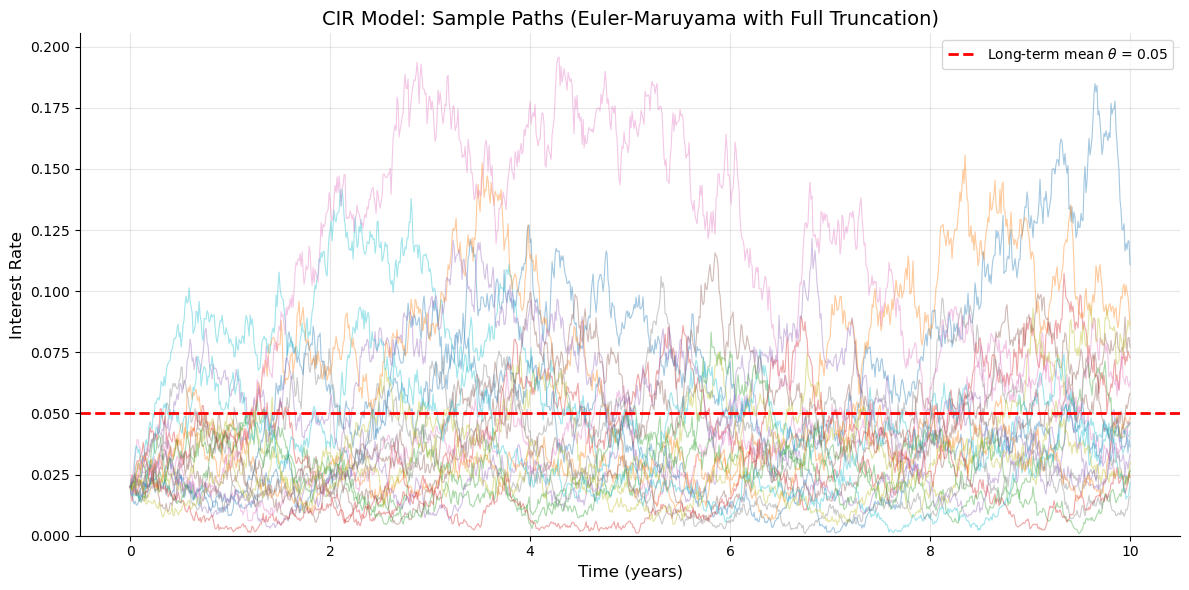

In [45]:
r0 = 0.02
kappa = 0.5
theta = 0.05
sigma = 0.15
T = 10
n_paths = 50
n_steps = 1000

t, r = simulate_cir(r0, kappa, theta, sigma, T, n_paths, n_steps)

fig, ax = plt.subplots(figsize=(12, 6))
for i in range(min(20, n_paths)):
    ax.plot(t, r[i], alpha=0.4, lw=0.8)

ax.axhline(y=theta, color='red', linestyle='--', lw=2, 
           label=rf'Long-term mean $\theta$ = {theta}')
ax.set_xlabel('Time (years)', fontsize=12)
ax.set_ylabel('Interest Rate', fontsize=12)
ax.set_title('CIR Model: Sample Paths (Euler-Maruyama with Full Truncation)', 
             fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


## About the Simulation
We use the full truncation scheme for the Euler-Maruyama discretization. At each step:

$r_{i+1} = r_i + \kappa (\theta - r_i^+) \Delta t + \sigma \sqrt{r_i^+} \Delta W_i$

where $r_i^+ = \max(0, r_i)$. This is the most robust scheme for CIR — it prevents the square root of a negative number and keeps the drift pulling the process upward when near zero.


## Distribution at Maturity vs Exact Density

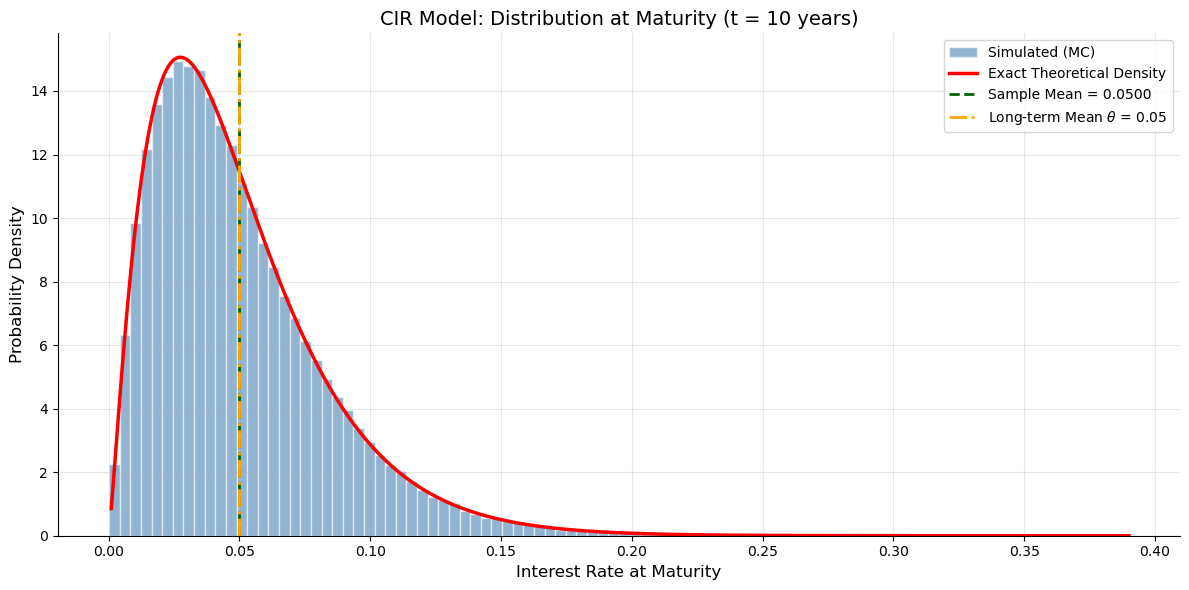

In [46]:
n_paths_large = 100000
t_large, r_large = simulate_cir(r0, kappa, theta, sigma, T, n_paths_large, n_steps)
r_maturity = r_large[:, -1]
r_maturity = r_maturity[r_maturity > 0]

x_range = np.linspace(0.001, max(r_maturity) * 1.2, 500)
theoretical = cir_exact_density(x_range, r0, kappa, theta, sigma, T)

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(r_maturity, bins=80, density=True, alpha=0.6, color='steelblue',
        edgecolor='white', label='Simulated (MC)')
ax.plot(x_range, theoretical, 'r-', lw=2.5, label='Exact Theoretical Density')

mean_mc = np.mean(r_maturity)
ax.axvline(x=mean_mc, color='darkgreen', linestyle='--', lw=2,
           label=f'Sample Mean = {mean_mc:.4f}')
ax.axvline(x=theta, color='orange', linestyle='-.', lw=2,
           label=rf'Long-term Mean $\theta$ = {theta}')

ax.set_xlabel('Interest Rate at Maturity', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title('CIR Model: Distribution at Maturity (t = 10 years)', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


## Exact Transition Density

The CIR process has a known exact transition density. If $r(0) = r_0$, then at time $t$:

$2c \cdot r(t) \sim \chi^2(2q+2,\lambda)$

where:
 
- $c = \dfrac{2\kappa}{\sigma^2(1 - e^{-\kappa t})}$
- $q = \dfrac{2\kappa\theta}{\sigma^2} - 1$
- $\lambda = 2c \cdot r_0 e^{-\kappa t}$

This is a non-central chi-square distribution. The plot above shows near-perfect agreement between Monte Carlo simulation and the exact theoretical density.

## Mean Reversion Over Time

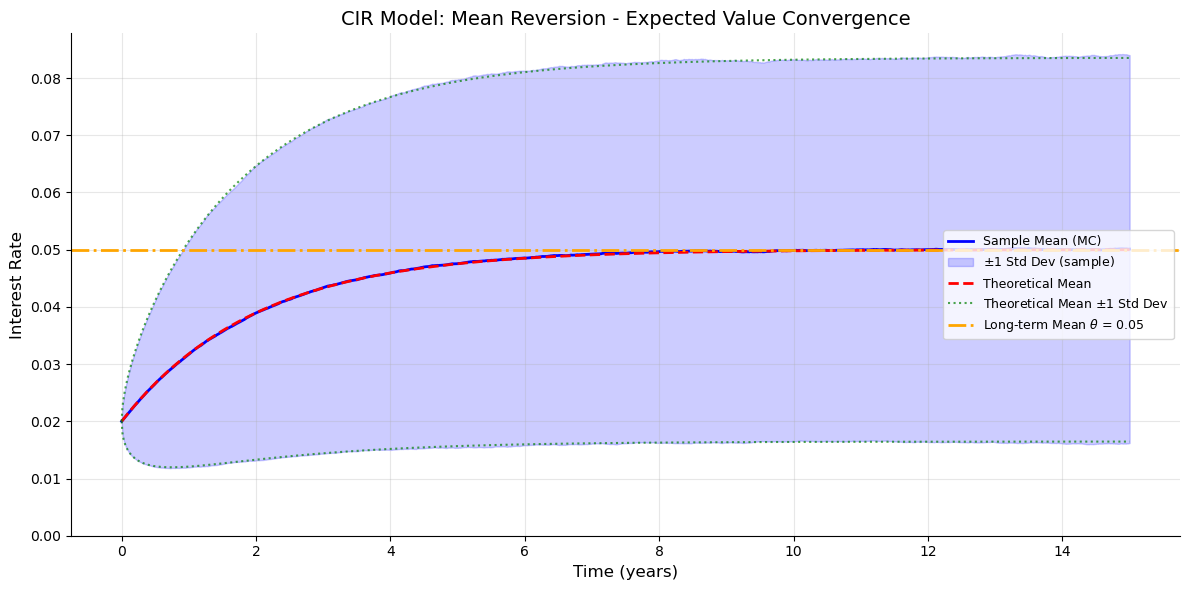

In [47]:
T_long = 15
n_steps_long = 1500
t_long, r_long = simulate_cir(r0, kappa, theta, sigma, T_long, 50000, n_steps_long)

theoretical_mean = r0 * np.exp(-kappa * t_long) + theta * (1 - np.exp(-kappa * t_long))
theoretical_var = (
    r0 * (sigma**2 / kappa) * (np.exp(-kappa * t_long) - np.exp(-2 * kappa * t_long))
    + theta * (sigma**2 / (2 * kappa)) * (1 - np.exp(-kappa * t_long))**2
)

sample_mean = np.mean(r_long, axis=0)
sample_std = np.std(r_long, axis=0)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(t_long, sample_mean, 'b-', lw=2, label='Sample Mean (MC)')
ax.fill_between(t_long, sample_mean - sample_std, sample_mean + sample_std,
                alpha=0.2, color='blue', label=r'$\pm$1 Std Dev (sample)')

ax.plot(t_long, theoretical_mean, 'r--', lw=2, label='Theoretical Mean')
ax.plot(t_long, theoretical_mean + np.sqrt(theoretical_var), 'g:', lw=1.5, 
        alpha=0.7, label='Theoretical Mean $\pm$1 Std Dev')
ax.plot(t_long, theoretical_mean - np.sqrt(theoretical_var), 'g:', lw=1.5, alpha=0.7)

ax.axhline(y=theta, color='orange', linestyle='-.', lw=2,
           label=rf'Long-term Mean $\theta$ = {theta}')

ax.set_xlabel('Time (years)', fontsize=12)
ax.set_ylabel('Interest Rate', fontsize=12)
ax.set_title('CIR Model: Mean Reversion - Expected Value Convergence', fontsize=14)
ax.legend(fontsize=9, loc='right')
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


## Mean Reversion Explained

Notice how:
 
- The expected value (red dashed) starts at $r_0 = 0.02$ and exponentially converges to $\theta = 0.05$
- Higher $\kappa$ means faster convergence
- The variance initially grows, then stabilizes as the process reaches its stationary regime
- The sample mean (blue) from 50,000 Monte Carlo paths overlays the theoretical mean almost perfectly

## Feller Condition

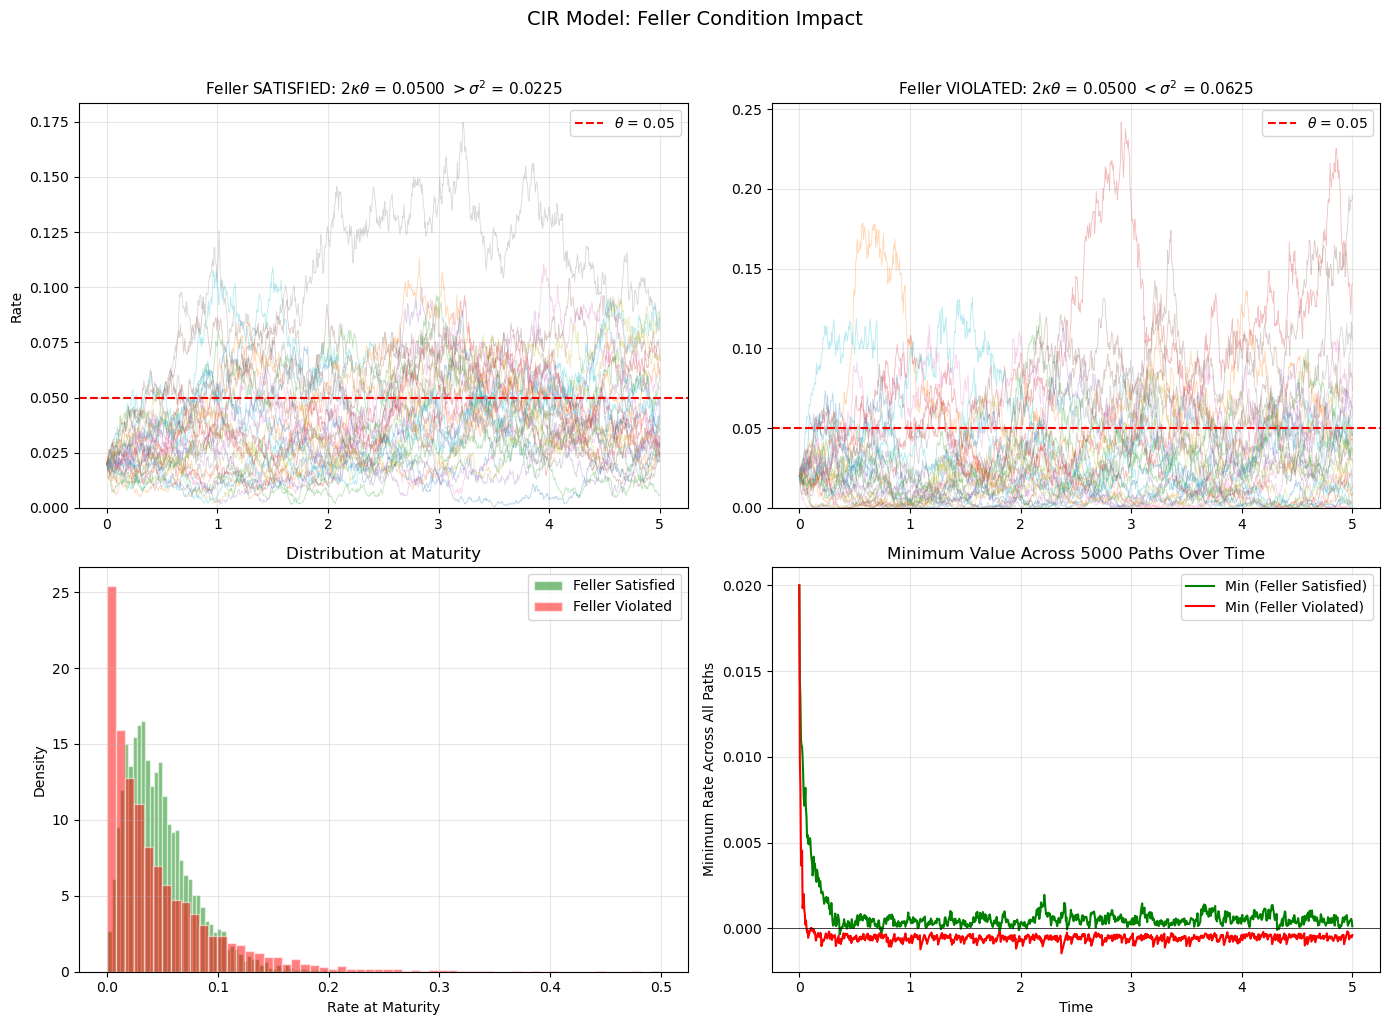

In [48]:
r0_f = 0.02
kappa_f = 0.5
theta_f = 0.05
sigma_satisfied = 0.15   # 2*kappa*theta = 0.05 > 0.0225
sigma_violated = 0.25    # 2*kappa*theta = 0.05 < 0.0625

T_f = 5
n_paths_f = 5000
n_steps_f = 1000

t_f, r_satisfied = simulate_cir(r0_f, kappa_f, theta_f, sigma_satisfied, 
                                T_f, n_paths_f, n_steps_f)
_, r_violated = simulate_cir(r0_f, kappa_f, theta_f, sigma_violated,
                             T_f, n_paths_f, n_steps_f)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Satisfied
ax = axes[0, 0]
for i in range(min(30, n_paths_f)):
    ax.plot(t_f, r_satisfied[i], alpha=0.3, lw=0.6)
ax.axhline(y=theta_f, color='red', linestyle='--', lw=1.5, label=rf'$\theta$ = {theta_f}')
ax.set_title(rf'Feller SATISFIED: $2\kappa\theta$ = {2*kappa_f*theta_f:.4f} '
             rf'$> \sigma^2$ = {sigma_satisfied**2:.4f}', fontsize=11)
ax.set_ylabel('Rate')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

# Violated
ax = axes[0, 1]
for i in range(min(30, n_paths_f)):
    ax.plot(t_f, r_violated[i], alpha=0.3, lw=0.6)
ax.axhline(y=theta_f, color='red', linestyle='--', lw=1.5, label=rf'$\theta$ = {theta_f}')
ax.set_title(rf'Feller VIOLATED: $2\kappa\theta$ = {2*kappa_f*theta_f:.4f} '
             rf'$< \sigma^2$ = {sigma_violated**2:.4f}', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

# Distributions
ax = axes[1, 0]
ax.hist(r_satisfied[:, -1], bins=60, density=True, alpha=0.5, color='green',
        edgecolor='white', label='Feller Satisfied')
ax.hist(r_violated[:, -1], bins=60, density=True, alpha=0.5, color='red',
        edgecolor='white', label='Feller Violated')
ax.set_xlabel('Rate at Maturity')
ax.set_ylabel('Density')
ax.set_title('Distribution at Maturity')
ax.legend()
ax.grid(True, alpha=0.3)

# Minimum over time
ax = axes[1, 1]
min_satisfied = np.min(r_satisfied, axis=0)
min_violated = np.min(r_violated, axis=0)
ax.plot(t_f, min_satisfied, 'g-', lw=1.5, label='Min (Feller Satisfied)')
ax.plot(t_f, min_violated, 'r-', lw=1.5, label='Min (Feller Violated)')
ax.axhline(y=0, color='black', linestyle='-', lw=0.5)
ax.set_xlabel('Time')
ax.set_ylabel('Minimum Rate Across All Paths')
ax.set_title('Minimum Value Across 5000 Paths Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('CIR Model: Feller Condition Impact', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Feller Condition Interpretation

|  Condition  |  Result  |
|-------------|----------|
|  2\kappa\theta > \sigma^2  |  Process stays strictly positive forever	
|  2\kappa\theta = \sigma^2  |  Process can touch zero but immediately bounces back	
|  2\kappa\theta < \sigma^2  |  Process can hit zero and spend time there	

In the violated case (top right), notice the paths cluster more densely near zero, and the minimum value plot (bottom right) shows the process spending time at or very near zero — consistent with the theoretical prediction.

##  Parameter Sensitivity

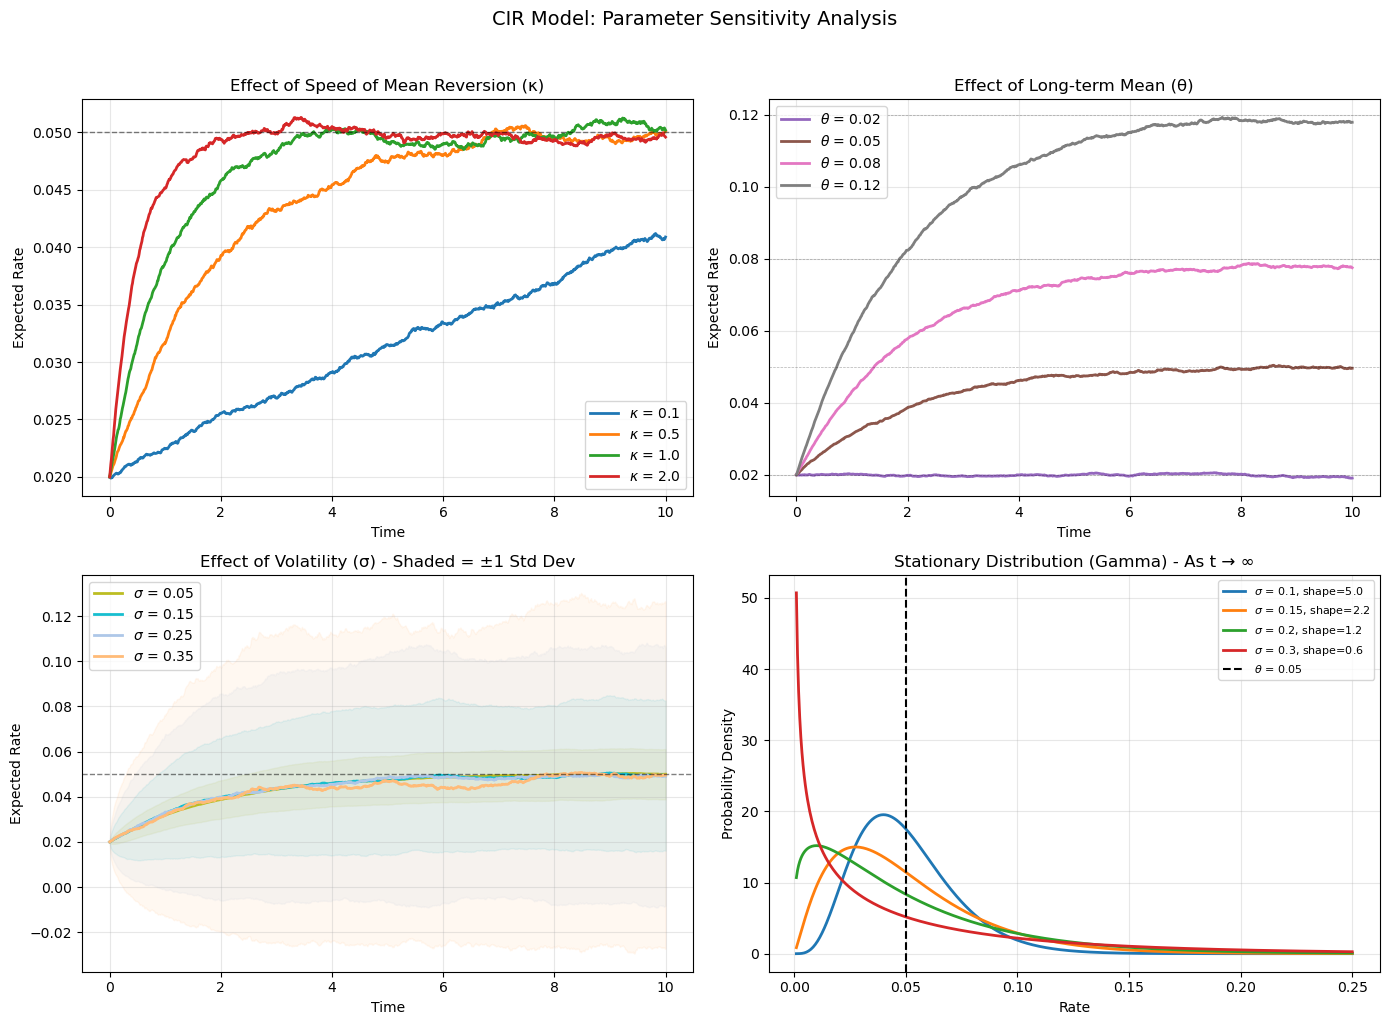

In [49]:
T_sens = 10
n_paths_sens = 2000
n_steps_sens = 1000

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Kappa effect
ax = axes[0, 0]
kappa_values = [0.1, 0.5, 1.0, 2.0]
colors_k = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for kappa_val, color in zip(kappa_values, colors_k):
    _, r_k = simulate_cir(r0, kappa_val, theta, sigma, T_sens, n_paths_sens, n_steps_sens)
    mean_k = np.mean(r_k, axis=0)
    ax.plot(np.linspace(0, T_sens, n_steps_sens + 1), mean_k, color=color, lw=2,
            label=rf'$\kappa$ = {kappa_val}')
ax.axhline(y=theta, color='black', linestyle='--', lw=1, alpha=0.5)
ax.set_title('Effect of Speed of Mean Reversion (κ)')
ax.set_xlabel('Time')
ax.set_ylabel('Expected Rate')
ax.legend()
ax.grid(True, alpha=0.3)

# Theta effect
ax = axes[0, 1]
theta_values = [0.02, 0.05, 0.08, 0.12]
colors_t = ['#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
for theta_val, color in zip(theta_values, colors_t):
    _, r_t = simulate_cir(r0, kappa, theta_val, sigma, T_sens, n_paths_sens, n_steps_sens)
    mean_t = np.mean(r_t, axis=0)
    ax.plot(np.linspace(0, T_sens, n_steps_sens + 1), mean_t, color=color, lw=2,
            label=rf'$\theta$ = {theta_val}')
for theta_val in theta_values:
    ax.axhline(y=theta_val, color='black', linestyle='--', lw=0.5, alpha=0.3)
ax.set_title('Effect of Long-term Mean (θ)')
ax.set_xlabel('Time')
ax.set_ylabel('Expected Rate')
ax.legend()
ax.grid(True, alpha=0.3)

# Sigma effect
ax = axes[1, 0]
sigma_values = [0.05, 0.15, 0.25, 0.35]
colors_s = ['#bcbd22', '#17becf', '#aec7e8', '#ffbb78']
for sigma_val, color in zip(sigma_values, colors_s):
    _, r_s = simulate_cir(r0, kappa, theta, sigma_val, T_sens, n_paths_sens, n_steps_sens)
    mean_s = np.mean(r_s, axis=0)
    std_s = np.std(r_s, axis=0)
    t_grid = np.linspace(0, T_sens, n_steps_sens + 1)
    ax.plot(t_grid, mean_s, color=color, lw=2, label=rf'$\sigma$ = {sigma_val}')
    ax.fill_between(t_grid, mean_s - std_s, mean_s + std_s, alpha=0.1, color=color)
ax.axhline(y=theta, color='black', linestyle='--', lw=1, alpha=0.5)
ax.set_title('Effect of Volatility (σ) - Shaded = ±1 Std Dev')
ax.set_xlabel('Time')
ax.set_ylabel('Expected Rate')
ax.legend()
ax.grid(True, alpha=0.3)

# Stationary distribution
ax = axes[1, 1]
sigma_vals_stat = [0.10, 0.15, 0.20, 0.30]
x_stat = np.linspace(0.001, 0.25, 500)
for sigma_val in sigma_vals_stat:
    shape = 2 * kappa * theta / (sigma_val**2)
    scale = sigma_val**2 / (2 * kappa)
    gamma_pdf = stats.gamma.pdf(x_stat, shape, scale=scale)
    ax.plot(x_stat, gamma_pdf, lw=2,
            label=rf'$\sigma$ = {sigma_val}, shape={shape:.1f}')
ax.axvline(x=theta, color='black', linestyle='--', lw=1.5, label=rf'$\theta$ = {theta}')
ax.set_title('Stationary Distribution (Gamma) - As t → ∞')
ax.set_xlabel('Rate')
ax.set_ylabel('Probability Density')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('CIR Model: Parameter Sensitivity Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Parameter Insights

- $\kappa$ *(speed)*: Higher $\kappa$ means faster mean reversion. The process "forgets" its initial condition quickly.
- $\theta$ *(long-term mean)*: Simply shifts the equilibrium level. All curves converge to their respective \theta.
- $\sigma$ *(volatility)*: Higher $\sigma$ increases the spread (shaded bands) but does not change the long-term mean. Note that very high $\sigma$ violates the Feller condition, pushing mass toward zero.
- *Stationary distribution*: As $t \to \infty$, the process converges to a Gamma distribution. Lower \sigma gives a sharper, more concentrated distribution around $\theta$.

## CIR vs Vasicek

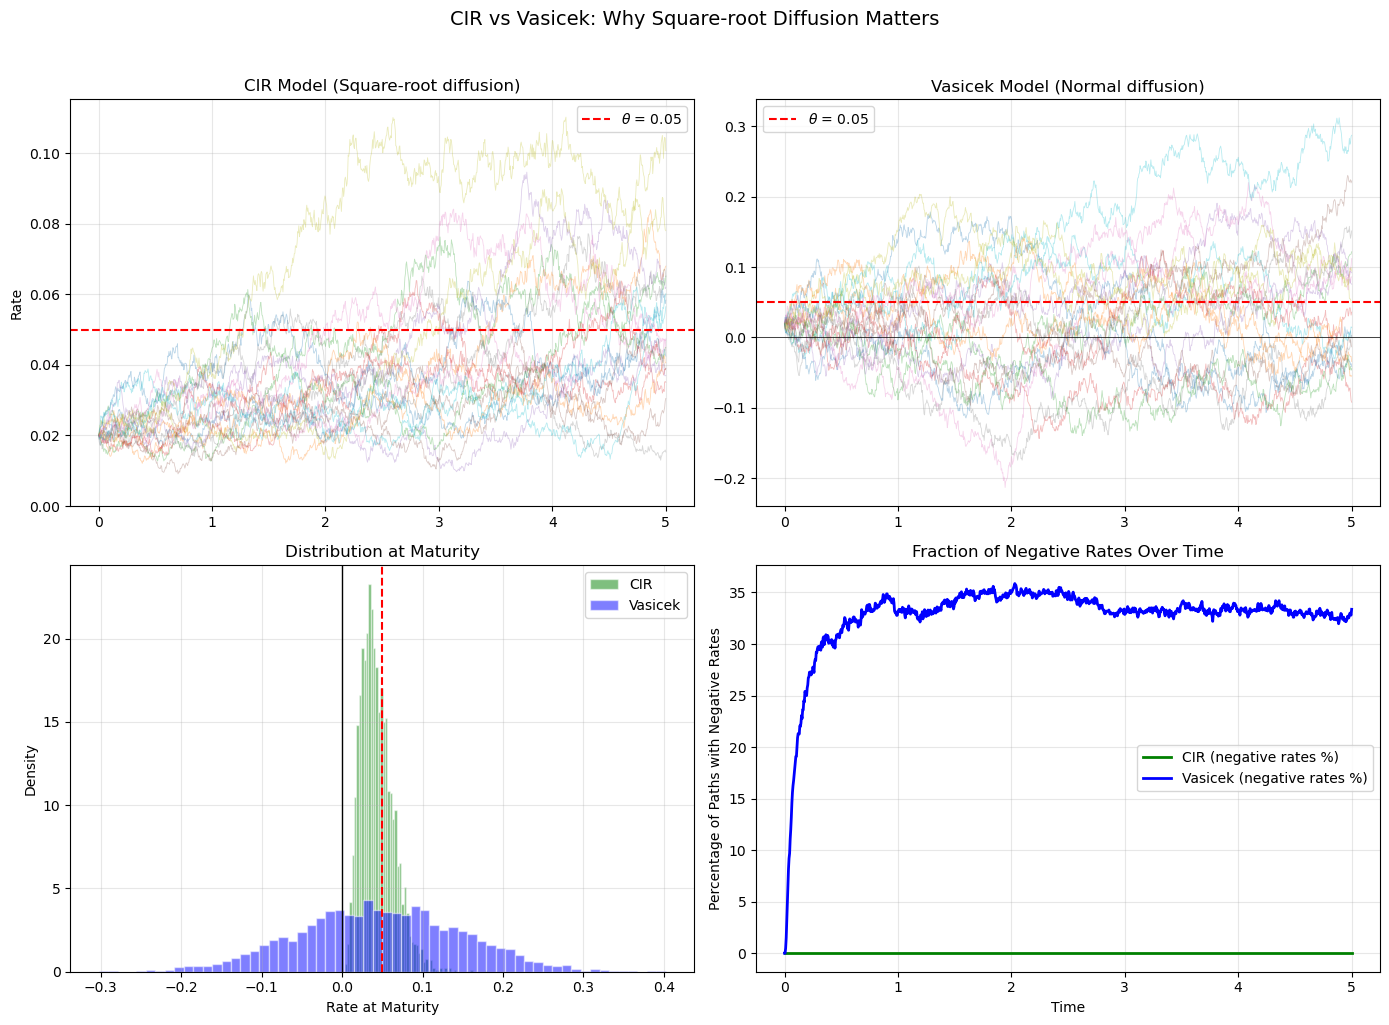

In [50]:
def simulate_vasicek(r0, kappa, theta, sigma, T, n_paths, n_steps):
    """Simulate Vasicek process (allows negative rates)."""
    dt = T / n_steps
    t = np.linspace(0, T, n_steps + 1)
    r = np.zeros((n_paths, n_steps + 1))
    r[:, 0] = r0
    for i in range(n_steps):
        dW = np.random.normal(0, np.sqrt(dt), n_paths)
        r[:, i + 1] = r[:, i] + kappa * (theta - r[:, i]) * dt + sigma * dW
    return t, r


T_comp = 5
n_paths_comp = 3000
n_steps_comp = 1000

r0_c = 0.02
kappa_c = 0.3
theta_c = 0.05
sigma_c = 0.08

t_c, r_cir = simulate_cir(r0_c, kappa_c, theta_c, sigma_c, T_comp, n_paths_comp, n_steps_comp)
_, r_vas = simulate_vasicek(r0_c, kappa_c, theta_c, sigma_c, T_comp, n_paths_comp, n_steps_comp)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# CIR paths
ax = axes[0, 0]
for i in range(min(20, n_paths_comp)):
    ax.plot(t_c, r_cir[i], alpha=0.3, lw=0.6)
ax.axhline(y=theta_c, color='red', linestyle='--', lw=1.5, label=rf'$\theta$ = {theta_c}')
ax.set_title('CIR Model (Square-root diffusion)')
ax.set_ylabel('Rate')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

# Vasicek paths
ax = axes[0, 1]
for i in range(min(20, n_paths_comp)):
    ax.plot(t_c, r_vas[i], alpha=0.3, lw=0.6)
ax.axhline(y=theta_c, color='red', linestyle='--', lw=1.5, label=rf'$\theta$ = {theta_c}')
ax.axhline(y=0, color='black', linestyle='-', lw=0.5)
ax.set_title('Vasicek Model (Normal diffusion)')
ax.legend()
ax.grid(True, alpha=0.3)

# Distributions
ax = axes[1, 0]
ax.hist(r_cir[:, -1], bins=60, density=True, alpha=0.5, color='green',
        edgecolor='white', label='CIR')
ax.hist(r_vas[:, -1], bins=60, density=True, alpha=0.5, color='blue',
        edgecolor='white', label='Vasicek')
ax.axvline(x=0, color='black', linestyle='-', lw=1)
ax.axvline(x=theta_c, color='red', linestyle='--', lw=1.5)
ax.set_xlabel('Rate at Maturity')
ax.set_ylabel('Density')
ax.set_title('Distribution at Maturity')
ax.legend()
ax.grid(True, alpha=0.3)

# Negative rates
ax = axes[1, 1]
frac_negative_cir = np.mean(r_cir < 0, axis=0) * 100
frac_negative_vas = np.mean(r_vas < 0, axis=0) * 100
ax.plot(t_c, frac_negative_cir, 'g-', lw=2, label='CIR (negative rates %)')
ax.plot(t_c, frac_negative_vas, 'b-', lw=2, label='Vasicek (negative rates %)')
ax.set_xlabel('Time')
ax.set_ylabel('Percentage of Paths with Negative Rates')
ax.set_title('Fraction of Negative Rates Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('CIR vs Vasicek: Why Square-root Diffusion Matters', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Why CIR Wins Over Vasicek

|  Feature  |  CIR  |  Vasicek  |
|-----------|-------|-----------|
|  SDE  |  $dr = \kappa(\theta-r)dt + \sigma\sqrt{r}\,dW$  |  $dr = \kappa(\theta-r)dt + \sigma\,dW$  |
|  Volatility  |  Scales with $\sqrt{r}$  |  Constant  |
|  Negative rates?  |  No (if Feller holds)  |  Yes — normal distribution  |
|  Distribution  |  Non-central $\chi^2$ (skewed)  |  Normal (symmetric)  | 
|  Use case  |  Interest rates, volatility  |Theoretical benchmark  |


The bottom-right panel is striking: *CIR has 0% negative rates*, while *Vasicek settles at ~33% negative rates* for these parameters. This is why CIR became the industry standard for interest rate modeling before the era of negative policy rates.